In [1]:
import os
os.chdir('..')

In [3]:
%load_ext autoreload
%autoreload 2
from dataset.chatter_image import ChatterImage
from model.cnn import CNN


from trainer.classifier import ClassifierTrainer
import torch
import numpy as np
import os
from torchvision import transforms
from utils.plot_utils import plot_confusion_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
SEED = 47
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [14]:
hyperparams = dict(lr=0.001, train_batch_size=8, test_batch_size=8, epoch=50, train_shuffle=True, test_shuffle=False)
params = dict(log_interval=10, result_path='../results/chatter_cnn_images')

In [10]:
dataset = ChatterImage(root='D:/YandexDisk/machining/chatter_cnn_images/Chatter_cnn',
                           transform=transforms.Compose([transforms.ToTensor()]),
                           )

Reading images...: 100%|██████████████████████████████████████████████████████████▉| 1518/1519 [00:35<00:00, 43.15it/s]


====== Trainset Info ======

                data.shape:(1138, 200, 5120)
                targets.shape:(1138,)
                targets.mean: 0.4209138751029968
        
====== Testset Info ======

                data.shape:(380, 200, 5120)
                targets.shape:(380,)
                targets.mean: 0.7605262994766235
        


In [11]:
model = CNN(in_channels=1, out_channels=1)

In [15]:
trainer = ClassifierTrainer(model=model, dataset=dataset, hyperparams=hyperparams, params=params)

In [16]:
trainer.fit()

Test	Epoch: 0 [0/380 (0%)]	Batch Loss: 1.740085	Batch Acc: 50.0
Test	Epoch: 0 [80/380 (21%)]	Batch Loss: 0.000000	Batch Acc: 100.0
Test	Epoch: 0 [160/380 (42%)]	Batch Loss: 2.669152	Batch Acc: 12.0
Test	Epoch: 0 [240/380 (62%)]	Batch Loss: 1.489806	Batch Acc: 25.0
Test	Epoch: 0 [320/380 (83%)]	Batch Loss: 0.000001	Batch Acc: 100.0
Train	Epoch: 1 [0/1138 (0%)]	Batch Loss: 0.195418	Batch Acc: 88.0
Train	Epoch: 1 [80/1138 (7%)]	Batch Loss: 0.031175	Batch Acc: 100.0
Train	Epoch: 1 [160/1138 (14%)]	Batch Loss: 0.042864	Batch Acc: 100.0
Train	Epoch: 1 [240/1138 (21%)]	Batch Loss: 0.135572	Batch Acc: 88.0
Train	Epoch: 1 [320/1138 (28%)]	Batch Loss: 0.003258	Batch Acc: 100.0
Train	Epoch: 1 [400/1138 (35%)]	Batch Loss: 0.005499	Batch Acc: 100.0
Train	Epoch: 1 [480/1138 (42%)]	Batch Loss: 0.001565	Batch Acc: 100.0
Train	Epoch: 1 [560/1138 (49%)]	Batch Loss: 0.007080	Batch Acc: 100.0
Train	Epoch: 1 [640/1138 (56%)]	Batch Loss: 0.017133	Batch Acc: 100.0
Train	Epoch: 1 [720/1138 (63%)]	Batch Loss: 

In [17]:
trainer.history.save(fpath=params['result_path'])
trainer.history.plot(fpath=params['result_path'])

In [38]:
train_prediction = trainer.predict(dataloader=trainer.train_loader)

In [36]:
test_prediction = trainer.predict()

In [39]:
train_true = trainer.dataset.trainset.targets
test_true = trainer.dataset.testset.targets

<Figure size 432x288 with 0 Axes>

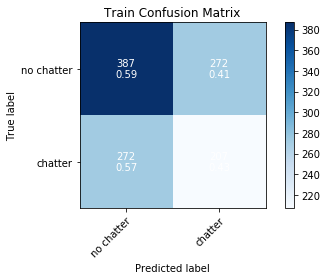

In [40]:
plot_confusion_matrix(y_true=train_true,
                      y_pred=train_prediction, 
                      classes=['no chatter', 'chatter'],
                     title='Train Confusion Matrix',
                     save_path=params['result_path']+'/train_cm')

<Figure size 432x288 with 0 Axes>

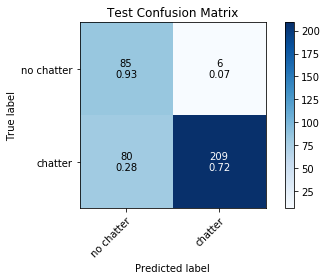

In [41]:
plot_confusion_matrix(y_true=test_true,
                      y_pred=test_prediction, 
                      classes=['no chatter', 'chatter'],
                     title='Test Confusion Matrix',
                     save_path=params['result_path']+'/test_cm')

In [42]:
trainer.model

CNN(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 20, kernel_size=(3, 6), stride=(1, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=(3, 6), stride=(3, 6), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(20, 50, kernel_size=(3, 6), stride=(1, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=(3, 6), stride=(3, 6), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(50, 10, kernel_size=(3, 6), stride=(1, 2))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=(3, 6), stride=(3, 6), padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=120, out_features=100, bias=True)
    (1): Linear(in_features=100, out_features=1, bias=True)
  )
)